In [5]:
import os
from torchvision import io, utils
from pycocotools.coco import COCO
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from pycocotools.cocoeval import COCOeval
from torchvision.datasets import CocoDetection
import torch
import torch.nn as nn
from torchvision.transforms.functional import to_tensor
import pytorch_lightning as pl
import json
import pandas as pd

from transformers import (
    DeformableDetrForObjectDetection,
    DeformableDetrImageProcessor
)

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# PARAMETERS
NUM_CLASSES = 7 # 7 classes
EPOCHS = 100
MODEL_TYPE = "defdetr"
VERSION = "1_puro"
CHECKPOINT = "./deformable-detr-finetuned-asphalt/version_12/checkpoints/best-epoch=92-val_loss=0.00.ckpt"
EVALUATION_RESULTS_FOLDER = "./evaluation_results"


# Caminhos do dataset
ROOT_DIR = "../../SVRDD_COCO"
TRAIN_DIRECTORY = os.path.join(ROOT_DIR, "train")
VAL_DIRECTORY = os.path.join(ROOT_DIR, "valid")
TEST_DIRECTORY = os.path.join(ROOT_DIR, "test")
ANNOTATION_FILE_NAME = "_annotations.coco.json"
DETECTIONS_PATH = "detections.json"
CLASSES = {
    0: "longitudinal crack",
    1: "transverse crack",
    2: "alligator crack",
    3: "pothole",
    4: "manhole cover",
    5: "longitudinal patch",
    6: "transverse patch",
}

In [7]:
model_name = "SenseTime/deformable-detr"

class DeformableDetr(pl.LightningModule): # Mude o nome da classe para clareza
    def __init__(self, lr, lr_backbone, weight_decay):
        super().__init__()

        print("Initializing PRETRAINED MODEL")
        self.model = DeformableDetrForObjectDetection.from_pretrained(
            pretrained_model_name_or_path=model_name, 
            num_labels=NUM_CLASSES,
            ignore_mismatched_sizes=True
        )
        print("PRETRAINED MODEL INITIALIZED")
            
        self.reinit_detection_heads()
        self.lr = lr
        self.lr_backbone = lr_backbone
        self.weight_decay = weight_decay

    def reinit_detection_heads(self):
        for name, module in self.model.named_modules():
            if "class_embed" in name or "bbox_embed" in name:
                for pn, p in module.named_parameters(recurse=False):
                    with torch.no_grad():
                        if p.dim() > 1:
                            nn.init.xavier_uniform_(p)
                        else:
                            p.zero_()
        print("Heads (class_embed / bbox_embed) reinicializadas.")
    
    def forward(self, pixel_values, pixel_mask):
        return self.model(pixel_values=pixel_values, pixel_mask=pixel_mask)

    def common_step(self, batch, batch_idx):
        # Move explicitamente para o device
        pixel_values = batch["pixel_values"].to(self.device)
        pixel_mask = batch["pixel_mask"].to(self.device)
        labels = [{k: v.to(self.device) for k, v in t.items()} for t in batch["labels"]]
    
        outputs = self.model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=labels)
    
        loss = outputs.loss
        loss_dict = outputs.loss_dict
        return loss, loss_dict

    def training_step(self, batch, batch_idx):
        loss, loss_dict = self.common_step(batch, batch_idx)     
        # logs metrics for each training_step, and the average across the epoch
        self.log("training_loss", loss)
        for k,v in loss_dict.items():
            self.log("train_" + k, v.item())

        return loss

    def validation_step(self, batch, batch_idx):
        loss, loss_dict = self.common_step(batch, batch_idx)     
        self.log("validation/loss", loss)
        for k, v in loss_dict.items():
            self.log("validation_" + k, v.item())
            
        return loss

    def configure_optimizers(self):
        # DETR authors decided to use different learning rate for backbone
        # you can learn more about it here: 
        # - https://github.com/facebookresearch/detr/blob/3af9fa878e73b6894ce3596450a8d9b89d918ca9/main.py#L22-L23
        # - https://github.com/facebookresearch/detr/blob/3af9fa878e73b6894ce3596450a8d9b89d918ca9/main.py#L131-L139
        param_dicts = [
            {
                "params": [p for n, p in self.named_parameters() if "backbone" not in n and p.requires_grad]},
            {
                "params": [p for n, p in self.named_parameters() if "backbone" in n and p.requires_grad],
                "lr": self.lr_backbone,
            },
        ]
        return torch.optim.AdamW(param_dicts, lr=self.lr, weight_decay=self.weight_decay)

    def train_dataloader(self):
        return TRAIN_DATALOADER

    def val_dataloader(self):
        return VAL_DATALOADER

In [8]:
def count_classes(coco_gt):
    # --- Contagem de instâncias ---
    cat_ids = coco_gt.getCatIds()
    cats = [coco_gt.loadCats([i])[0]["name"] for i in cat_ids]
    area_labels = ["small", "medium", "large"]

    counts_dict = {cat: {"small":0, "medium":0, "large":0} for cat in cats}
    ann_ids = coco_gt.getAnnIds()
    anns = coco_gt.loadAnns(ann_ids)

    for ann in anns:
        cat_name = coco_gt.loadCats([ann["category_id"]])[0]["name"]
        area = ann["area"]
        if area < 32**2:
            counts_dict[cat_name]["small"] += 1
        elif area < 96**2:
            counts_dict[cat_name]["medium"] += 1
        else:
            counts_dict[cat_name]["large"] += 1
    return cats, counts_dict


def evaluate_coco(dataset_dir, json_detection_path, excel_path="coco_results.xlsx"):

    GT_ANN_FILE = os.path.join(dataset_dir, ANNOTATION_FILE_NAME)

    # carregar ground truth
    coco_gt = COCO(GT_ANN_FILE)

    # carregar detecções
    coco_dt = coco_gt.loadRes(json_detection_path)

    # rodar avaliação
    coco_eval = COCOeval(coco_gt, coco_dt, iouType="bbox")
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    # métricas por classe
    cats, counts_dict = count_classes(coco_gt)

    # Converter para DataFrame
    df_counts = pd.DataFrame(counts_dict).T
    df_counts["total"] = df_counts.sum(axis=1)
    df_counts = df_counts[["total", "small", "medium", "large"]]
    print("\n=== Contagem de instâncias por classe e tamanho ===")
    print(df_counts)

    # --- Tabelas de métricas ---
    precisions = coco_eval.eval['precision']  # [TxRxKxAxM]
    iou_thrs = coco_eval.params.iouThrs
    iou50_idx = np.where(iou_thrs == 0.5)[0][0]
    maxDets_idx = 2  # normalmente corresponde a 100 maxDets
    area_labels_full = ["all", "small", "medium", "large"]
    metrics_tables = {}
    
    for a_idx, area in enumerate(area_labels_full):
        data = []
        for idx, cat in enumerate(cats):
            # mAP 0.50:0.95
            precision_all = precisions[:, :, idx, a_idx, maxDets_idx]
            precision_all = precision_all[precision_all > -1]
            mAP = np.mean(precision_all) if precision_all.size > 0 else np.nan

            # mAP50
            precision50 = precisions[iou50_idx, :, idx, a_idx, maxDets_idx]
            precision50 = precision50[precision50 > -1]
            mAP50 = np.mean(precision50) if precision50.size > 0 else np.nan

            # quantidade
            if area == "all":
                qty = df_counts.loc[cat, "total"]
            else:
                qty = df_counts.loc[cat, area]

            data.append([qty, mAP50, mAP])

        df_metrics = pd.DataFrame(data, columns=["Quantidade", "mAP50", "mAP50:0.95"], index=cats)
        metrics_tables[area] = df_metrics
        print(f"\n=== Métricas para tamanho '{area}' ===")
        print(df_metrics.round(3))

    # --- Exportar tudo para Excel ---
    with pd.ExcelWriter(excel_path) as writer:
        df_counts.round(3).to_excel(writer, sheet_name="counts")
        for area, df in metrics_tables.items():
            df.round(3).to_excel(writer, sheet_name=area)

    print(f"\n📁 Arquivo Excel exportado com sucesso para: {excel_path}")
    return coco_eval

def get_one_example_prediction(image_id: int, results: list):
    pred_box = []
    pred_label = []
    pred_score = []
    for i in range(len(results)):
        # Pegar todas as boxes , labels e scores do resultado que tiver image_id == x
        if results[i]["image_id"] == image_id + 1:
            pred_box.append(results[i]["bbox"])
            pred_label.append(results[i]["category_id"])
            pred_score.append(results[i]["score"])
        elif results[i]["image_id"] > image_id + 1:
            break

    pred_box = torch.tensor(pred_box)
    pred_label = torch.tensor(pred_label)
    pred_score = torch.tensor(pred_score)
    return pred_box, pred_label, pred_score

def coco_load_image(img_info: dict, dataset_dir: str):
    # Getting image tensor
    img_path = os.path.join(dataset_dir, img_info["file_name"])
    image = Image.open(img_path).convert("RGB")
    img_tensor = to_tensor(image).to(device)
    return img_tensor

def get_image_and_target(image_id: int, dataset_dir: str):
    
    # Getting dataset on coco format
    coco = COCO(os.path.join(dataset_dir, ANNOTATION_FILE_NAME))

    # Getting image tensor
    img_id = coco.getImgIds()[image_id]
    img_info = coco.loadImgs(img_id)[0]
    img_path = os.path.join(dataset_dir, img_info["file_name"])
    image = Image.open(img_path).convert("RGB")
    img_tensor = to_tensor(image).to(device)

    # Getting annotation target
    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)
    target = {
        "boxes": torch.tensor([ann["bbox"] for ann in anns], dtype=torch.float32).to(device),
        "labels": torch.tensor([ann["category_id"] for ann in anns], dtype=torch.int64).to(device),
    }
    target["boxes"][:, 2] = target["boxes"][:, 0] + target["boxes"][:, 2]
    target["boxes"][:, 3] = target["boxes"][:, 1] + target["boxes"][:, 3]
    return img_tensor, target


class CocoDetectionCustom(CocoDetection):
    # Herda a lógica de leitura de arquivos COCO do torchvision
    def __init__(self, image_directory_path: str, image_processor):
        annotation_file_path = os.path.join(image_directory_path, ANNOTATION_FILE_NAME)
        
        # O __init__ do CocoDetection carrega as anotações e os caminhos
        super(CocoDetectionCustom, self).__init__(image_directory_path, annotation_file_path)
        
        self.image_processor = image_processor

    def __getitem__(self, idx):
        # 1. Obter Imagem (PIL Image) e Anotações (lista COCO)
        image, annotations = super(CocoDetectionCustom, self).__getitem__(idx)
        image_id = self.ids[idx] # Obtém o ID da imagem do índice
        
        
        # 2. Formatar anotações para o processor do Hugging Face
        annotations = {'image_id': image_id, 'annotations': annotations}
        
        # 3. Processar a amostra (redimensionamento e conversão COCO -> DETR)
        # return_tensors="pt" é aplicado aqui, mas sem padding
        encoding = self.image_processor(images=image, annotations=annotations, return_tensors="pt")
        
        # 4. Retornar amostra sem a dimensão de batch (squeeze)
        return {
            "pixel_values": encoding["pixel_values"].squeeze(),
            "pixel_mask": encoding["pixel_mask"].squeeze(),
            "labels": encoding["labels"][0], # O labels é uma lista, pegamos o primeiro elemento
        }
    

class XYXYDatasetFromCOCO(CocoDetection):
    def __init__(self, image_directory_path: str):
        annotation_file_path = os.path.join(image_directory_path, ANNOTATION_FILE_NAME)
        super().__init__(image_directory_path, annotation_file_path)

    def __getitem__(self, idx):
        # super retorna (PIL Image, annotations list)
        img, anns = super().__getitem__(idx)

        # converte para Tensor float32 em [0,1]
        img = to_tensor(img)  # shape [C,H,W], dtype=float32

        boxes = []
        labels = []
        areas = []
        iscrowd = []

        for a in anns:
            xmin, ymin, w, h = a["bbox"]
            boxes.append([xmin, ymin, xmin + w, ymin + h])
            labels.append(a["category_id"])
            areas.append(w * h)
            iscrowd.append(a.get("iscrowd", 0))

        if len(boxes) == 0:
            # lidar com imagens sem anotações (opcional: pular na collate)
            boxes = torch.zeros((0,4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)
            areas = torch.tensor(areas, dtype=torch.float32)
            iscrowd = torch.tensor(iscrowd, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
        }

        return img, target

# DeformableDETR

Carregando modelo e processor...
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


Some weights of the model checkpoint at SenseTime/deformable-detr were not used when initializing DeformableDetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DeformableDetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DeformableDetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of DeformableDetrForObjectDetection wer

Heads (class_embed / bbox_embed) reinicializadas.
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Visualizing Prediction...


/venv/deformable/lib/python3.11/site-packages/torchvision/utils.py:352: UserWarning: boxes doesn't contain any box. No box was drawn
  warnings.warn("boxes doesn't contain any box. No box was drawn")


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

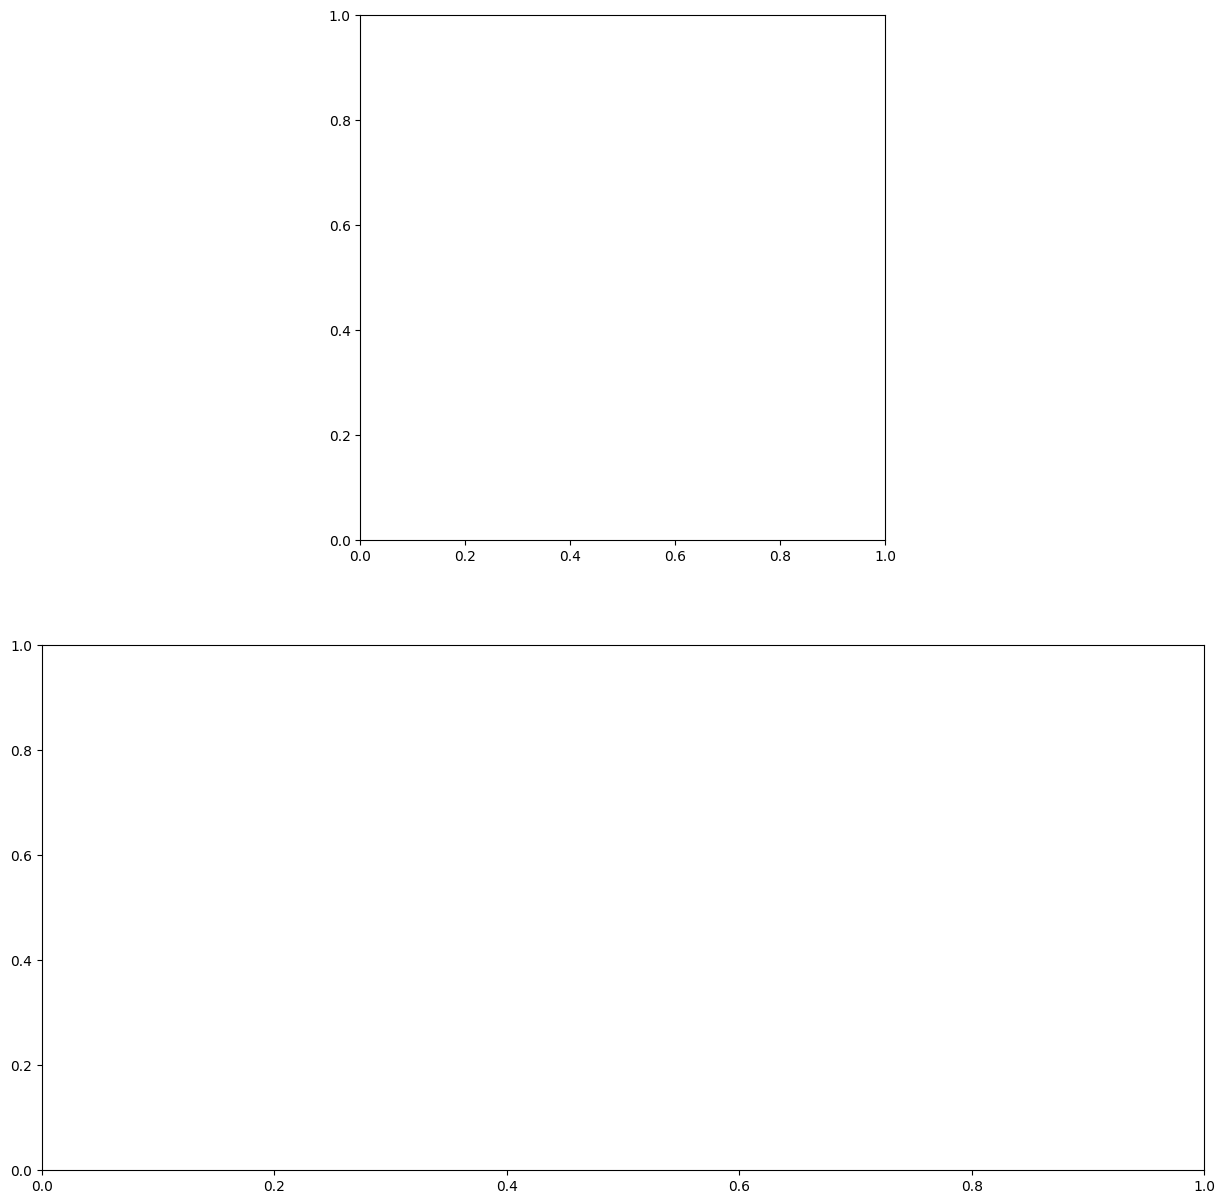

In [17]:
from torch.nn.functional import softmax

EVALUATE_DIRECTORY = VAL_DIRECTORY
device = "cuda"
image_size = (1024, 1024)
img_h, img_w = image_size
threshold = 0.3
IMG_ID = 0


print("Carregando modelo e processor...")
processor = DeformableDetrImageProcessor.from_pretrained(model_name)

EVALUATE_DATASET = CocoDetectionCustom(
    image_directory_path=EVALUATE_DIRECTORY, 
    image_processor=processor
)

model = DeformableDetr.load_from_checkpoint(
    checkpoint_path=CHECKPOINT, 
    lr=1e-4, 
    lr_backbone=1e-5, 
    weight_decay=1e-4
).to(device)

# Model Inference
model.eval()
pixel_values = EVALUATE_DATASET[IMG_ID]["pixel_values"].unsqueeze(0).to(device)
pixel_mask = EVALUATE_DATASET[IMG_ID]["pixel_mask"].unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(pixel_values, pixel_mask)

processed = processor.post_process_object_detection(
    outputs,
    threshold=threshold,
    target_sizes=[(img_h, img_w)]
)[0]

boxes = processed["boxes"].cpu()
scores = processed["scores"].cpu()
labels = processed["labels"].cpu()

img_tensor, target = get_image_and_target(IMG_ID, EVALUATE_DIRECTORY)


print("Visualizing Prediction...")
# Visualize predictions.
image_with_boxes = utils.draw_bounding_boxes(
    image=(img_tensor*255).to(torch.uint8),
    boxes=boxes,
    labels=[f"{CLASSES[label.item()]} {score:.3f}" for label, score in zip(labels, scores)],
)

fig, ax = plt.subplots(2, 1, figsize=(15, 15))
ax[0].imshow(image_with_boxes.permute(1, 2, 0))
ax[0].set_title("Predicted Boxes", fontsize=20)

print("Visualizing GroundTruth...")
# Visualize predictions.
image_with_boxes = utils.draw_bounding_boxes(
    image=(img_tensor * 255).to(torch.uint8),
    boxes=target["boxes"],
    labels=[f"{CLASSES[label.item()]}" for label in target["labels"]],
)
ax[1].imshow(image_with_boxes.permute(1, 2, 0))
ax[1].set_title("Ground Truth Boxes", fontsize=20)
fig.savefig("pred_ground_truth.png")
plt.show()

In [11]:
EVALUATE_DIRECTORY = TEST_DIRECTORY
json_detection_file = f'{os.path.basename(EVALUATE_DIRECTORY)}_{MODEL_TYPE}_{VERSION}_{DETECTIONS_PATH}'
json_detection_path = os.path.join(EVALUATION_RESULTS_FOLDER, json_detection_file)

In [15]:
EVALUATE_DIRECTORY = VAL_DIRECTORY
threshold = 0.0
REEVALUATE = True
image_size = (1024, 1024)
img_w, img_h = image_size


os.makedirs(EVALUATION_RESULTS_FOLDER, exist_ok=True)
json_detection_file = f'{os.path.basename(EVALUATE_DIRECTORY)}_{MODEL_TYPE}_{VERSION}_{DETECTIONS_PATH}'
json_detection_path = os.path.join(EVALUATION_RESULTS_FOLDER, json_detection_file) 
if REEVALUATE or not os.path.isfile(json_detection_path):
    
    ###################################################
    # Instantiating model                             #
    ###################################################
    
    print("Instantiating processor...")
    processor = DeformableDetrImageProcessor.from_pretrained(model_name)

    print("Instantiating model...")
    model = DeformableDetr.load_from_checkpoint(
        checkpoint_path=CHECKPOINT, 
        lr=1e-4, 
        lr_backbone=1e-5, 
        weight_decay=1e-4,
        #assign=True
    ).to(device)

    model.eval()
        
    ###################################################

    print("Loading Dataset...")
    EVAL_DETR_DATASET = CocoDetectionCustom(
        image_directory_path=EVALUATE_DIRECTORY, 
        image_processor=processor
    )
    
    EVALUATE_DATASET = COCO(os.path.join(EVALUATE_DIRECTORY, ANNOTATION_FILE_NAME))
    image_ids = EVALUATE_DATASET.getImgIds()
    
    # Model Inference
    all_preds = []
    for img_id in tqdm(image_ids, desc="Predicting on Dataset..."):
    
        img_info = EVALUATE_DATASET.loadImgs(img_id)[0]
        img_tensor = coco_load_image(img_info, EVALUATE_DIRECTORY)

        ###################################################
        # Model Predicting                                #
        ###################################################
        
        pixel_values = EVAL_DETR_DATASET[img_id - 1]["pixel_values"].unsqueeze(0).to(device)
        pixel_mask = EVAL_DETR_DATASET[img_id - 1]["pixel_mask"].unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(pixel_values, pixel_mask)

        processed = processor.post_process_object_detection(
            outputs,
            threshold=threshold,
            target_sizes=[(img_h, img_w)]
        )[0]
        
        ###################################################
        # Outputs Handling (box, label, score COCO format)#
        ###################################################
        
        boxes = processed["boxes"].cpu().numpy()
        scores = processed["scores"].cpu().numpy()
        labels = processed["labels"].cpu().numpy()
        
        # converter boxes para formato COCO: [x, y, w, h]
        boxes[:, 2] = boxes[:, 2] - boxes[:, 0]
        boxes[:, 3] = boxes[:, 3] - boxes[:, 1]
    
        ###################################################
        
        # montar cada previsão
        for box, score, label in zip(boxes, scores, labels):
            all_preds.append({
                "image_id": img_id,
                "category_id": int(label),
                "bbox": box.tolist(),
                "score": float(score)
            })
    with open(json_detection_path, "w") as f:
        json.dump(all_preds, f)

Instantiating processor...
Instantiating model...
Initializing PRETRAINED MODEL


/venv/deformable/lib/python3.11/site-packages/torch/nn/modules/module.py:2446: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/venv/deformable/lib/python3.11/site-packages/torch/nn/modules/module.py:2446: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/venv/deformable/lib/python3.11/site-packages/torch/nn/modules/module.py:2446: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (D

PRETRAINED MODEL INITIALIZED
Heads (class_embed / bbox_embed) reinicializadas.
Loading Dataset...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


Predicting on Dataset...:  50%|█████     | 505/1000 [00:52<00:51,  9.69it/s]


KeyboardInterrupt: 

In [16]:
excel_path = json_detection_path.replace(DETECTIONS_PATH, "coco_results.xlsx")
evaluate_coco(EVALUATE_DIRECTORY, json_detection_path, excel_path=excel_path)

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.95s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.24s).
Accumulating evaluation results...
DONE (t=0.32s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.140
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.298
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.107
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.015
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.081
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.212
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.191
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.373
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

## Example Prediction

Getting one example prediction...
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Visualizing Prediction...
Visualizing GroundTruth...


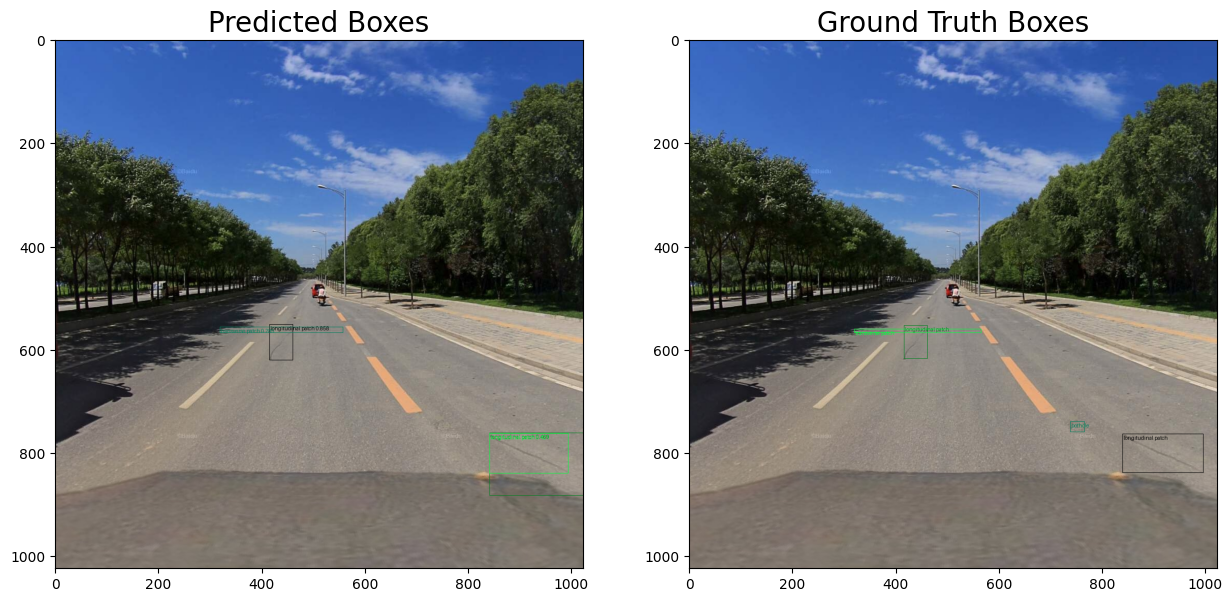

In [ ]:
# Example Prediction
image_id = 500
threshold = 0.25

with open(json_detection_path) as f:
    all_preds = json.load(f)
    
print("Getting one example prediction...")
pred_box, pred_label, pred_score = get_one_example_prediction(image_id, all_preds)

# Adjust to best threshold
keep = pred_score >= threshold
boxes = pred_box[keep]
labels = pred_label[keep]
scores = pred_score[keep]

# Convert boxes from COCO format [x, y, w, h] to xyxy [xmin, ymin, xmax, ymax]
boxes[:, 2] = boxes[:, 0] + boxes[:, 2]
boxes[:, 3] = boxes[:, 1] + boxes[:, 3]

# Getting image and annotation target
img_tensor, target = get_image_and_target(image_id, EVALUATE_DIRECTORY)

print("Visualizing Prediction...")
# Visualize predictions.
image_with_boxes = utils.draw_bounding_boxes(
    image=(img_tensor * 255).to(torch.uint8),
    boxes=boxes,
    labels=[f"{CLASSES[label.item()]} {score:.3f}" for label, score in zip(labels, scores)],
)

fig, ax = plt.subplots(1, 2, figsize=(15, 15))
ax[0].imshow(image_with_boxes.permute(1, 2, 0))

print("Visualizing GroundTruth...")
# Visualize predictions.
image_with_boxes = utils.draw_bounding_boxes(
    image=(img_tensor * 255).to(torch.uint8),
    boxes=target["boxes"],
    labels=[f"{CLASSES[label.item()]}" for label in target["labels"]],
)

# Colocar título nas imagens
ax[0].set_title("Predicted Boxes", fontsize=20)
ax[1].set_title("Ground Truth Boxes", fontsize=20)
ax[1].imshow(image_with_boxes.permute(1, 2, 0))
plt.show()